# **Mini Project 1: “Titanic Survival Prediction – Data Cleaning Project”**

### Upload CSV File



In [1]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  print(f"Successfully loaded '{fn}' into a DataFrame.")

# Display the first 5 rows of the DataFrame
display(df.head())

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
User uploaded file "Titanic-Dataset.csv" with length 61194 bytes
Successfully loaded 'Titanic-Dataset.csv' into a DataFrame.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Basic Data Summary



In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


### Descriptive Statistics


In [3]:
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Handling Missing Values

Based on the `df.info()` output, the 'Age' column has missing values (714 non-null out of 891 entries) and the 'Embarked' column has a few missing values (889 non-null out of 891 entries).

*   For 'Age' (numerical), we will use **median imputation**.
*   For 'Embarked' (categorical), we will use **mode imputation**.
*   The 'Cabin' column has too many missing values (only 204 non-null) and will be dropped as imputation would not be meaningful without further domain knowledge.

In [4]:
# Impute missing 'Age' values with the median
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# Impute missing 'Embarked' values with the mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# Drop 'Cabin' column due to a high number of missing values
df.drop('Cabin', axis=1, inplace=True)

print("Missing values after imputation and dropping 'Cabin':")
display(df.isnull().sum())

Missing values after imputation and dropping 'Cabin':


/tmp/ipykernel_2946/126732078.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)
/tmp/ipykernel_2946/126732078.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Encoding Categorical Variables

We need to convert categorical features ('Sex' and 'Embarked') into numerical formats suitable for machine learning models.

*   **'Sex'**: This is a binary categorical variable, so we can use `LabelEncoder`.
*   **'Embarked'**: This is a multi-class categorical variable, so we will use `OneHotEncoder` to avoid implying an ordinal relationship.

In [5]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Encode 'Sex' using LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# Encode 'Embarked' using OneHotEncoder
# Create a ColumnTransformer to apply OneHotEncoder to 'Embarked'
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), ['Embarked'])
    ],
    remainder='passthrough' # Keep other columns as they are
)

# Apply the transformation
df_encoded = ct.fit_transform(df)

# Get feature names for the one-hot encoded columns
# OneHotEncoder output is a sparse matrix, convert to array first
encoded_feature_names = ct.named_transformers_['encoder'].get_feature_names_out(['Embarked'])

# Create a new DataFrame with all columns (including original columns and new encoded ones)
# Need to convert the df_encoded array back to a DataFrame with correct column names
# The order of columns after ColumnTransformer is one-hot encoded features first, then remainder columns

# Get remaining column names in their original order
remaining_cols = [col for col in df.columns if col != 'Embarked']

# Combine new encoded feature names with remaining original column names (excluding original 'Embarked')
new_column_names = list(encoded_feature_names) + remaining_cols

df = pd.DataFrame(df_encoded, columns=new_column_names)

print("DataFrame after encoding 'Sex' and 'Embarked':")
display(df.head())

DataFrame after encoding 'Sex' and 'Embarked':


,Embarked_C,Embarked_Q,Embarked_S,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,0.0,0.0,1.0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.25
1,1.0,0.0,0.0,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833
2,0.0,0.0,1.0,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.925
3,0.0,0.0,1.0,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1
4,0.0,0.0,1.0,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.05


### Visualize Age Distribution

Let's visualize the distribution of the 'Age' column using a histogram to understand its spread and central tendency after imputation.

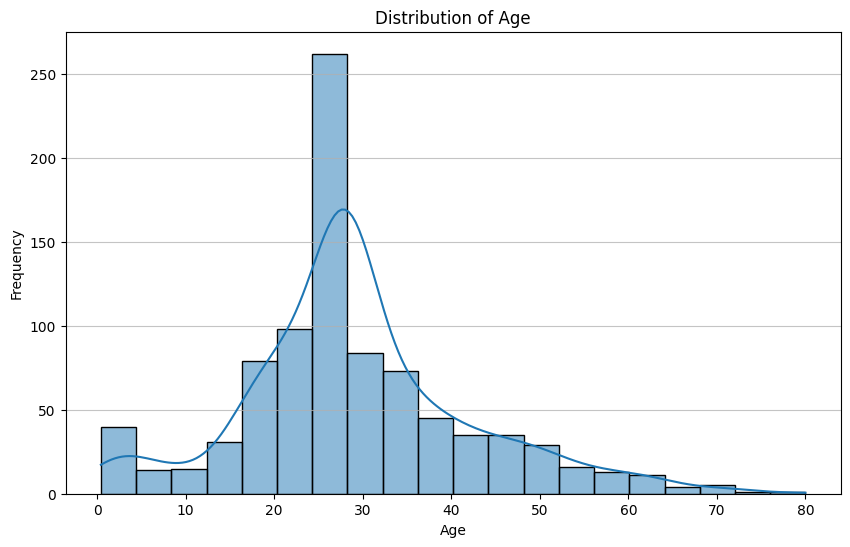

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Output Cleaned Dataset

Finally, let's save the cleaned DataFrame to a new CSV file. This new file will contain the data with missing values handled and categorical variables encoded.

In [7]:
df.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved to 'titanic_cleaned.csv'")

# Display the info of the cleaned dataframe to verify dtypes and non-null counts
print("\nInfo of the cleaned DataFrame:")
print(df.info())

Cleaned dataset saved to 'titanic_cleaned.csv'

Info of the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Embarked_C   891 non-null    object
 1   Embarked_Q   891 non-null    object
 2   Embarked_S   891 non-null    object
 3   PassengerId  891 non-null    object
 4   Survived     891 non-null    object
 5   Pclass       891 non-null    object
 6   Name         891 non-null    object
 7   Sex          891 non-null    object
 8   Age          891 non-null    object
 9   SibSp        891 non-null    object
 10  Parch        891 non-null    object
 11  Ticket       891 non-null    object
 12  Fare         891 non-null    object
dtypes: object(13)
memory usage: 90.6+ KB
None


### Download Cleaned Dataset



In [8]:
from google.colab import files

files.download('titanic_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>